In [12]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [13]:
# Load the preprocessed data
data = pd.read_csv('../Clustering_Analysis/dataset_with_clusters.csv')
data.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,Churn,InternetService_Fiber optic,Contract_One year,Contract_Two year,Cluster
0,0,0,0,-1.277445,0,0,-1.321350,1,False,False,False,2
1,1,0,0,0.351370,1,0,-1.321350,0,False,True,False,3
2,0,0,1,0.799294,1,0,-1.520755,0,False,False,False,3
3,0,0,0,-1.277445,1,0,0.373593,1,False,True,False,1
4,1,0,0,1.410099,1,0,-0.457261,0,True,False,False,3


In [14]:
# Splitting the data set into training and testing sets\

tf.random.set_seed(42)
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(data.drop('Churn', axis=1), data['Churn'], test_size=0.2, random_state=42, stratify=data['Churn'])

In [15]:
# Checking shape and distribution
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training set class distribution:\n", y_train.value_counts(normalize=True))
print("Testing set class distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (5634, 11)
Testing set shape: (1409, 11)
Training set class distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Testing set class distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [16]:
# Scaling the features
scaler = StandardScaler()

number_cols = ['tenure', 'MonthlyCharges']

# Fit the scaler on the training data and transform both training and testing data
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

print(X_train.head(),"\n")
print(X_train[['tenure', 'MonthlyCharges']].describe())

      gender  SeniorCitizen  Dependents    tenure  PhoneService  \
3757       1              0           1 -1.276682             1   
3165       0              0           0 -0.096089             1   
4912       0              1           0  0.555273             1   
3877       1              0           0  0.433143             1   
3818       1              0           0 -1.276682             1   

      MultipleLines  MonthlyCharges  InternetService_Fiber optic  \
3757              0       -0.149881                        False   
3165              0       -0.315125                        False   
4912              1        1.172071                         True   
3877              0        0.048412                        False   
3818              1       -1.471834                         True   

      Contract_One year  Contract_Two year  Cluster  
3757              False               True        2  
3165               True              False        1  
4912              False   

In [17]:
# Creating an ANN Model
model = Sequential([
    Dense(128, activation="elu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64, activation="elu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(16, activation="elu"),
    Dropout(0.15),

    Dense(1, activation="sigmoid")
])

/opt/homebrew/Caskroom/miniconda/base/envs/ACS-WILDA-Py3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Build class weights to handle class imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

In [19]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,617 (45.38 KB)

 Trainable params: 11,233 (43.88 KB)

 Non-trainable params: 384 (1.50 KB)

In [20]:
# Train the model with early stopping

early_stop = EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True)

history = model.fit(
X_train, y_train,
validation_split=0.2,
epochs=60,
batch_size=32,
callbacks=[early_stop],
verbose=1
)

Epoch 1/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7191 - auc: 0.7320 - loss: 0.5662 - val_accuracy: 0.7897 - val_auc: 0.8304 - val_loss: 0.4452
Epoch 2/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7621 - auc: 0.7734 - loss: 0.4961 - val_accuracy: 0.8048 - val_auc: 0.8327 - val_loss: 0.4294
Epoch 3/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7659 - auc: 0.7845 - loss: 0.4830 - val_accuracy: 0.7941 - val_auc: 0.8323 - val_loss: 0.4296
Epoch 4/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7681 - auc: 0.7866 - loss: 0.4784 - val_accuracy: 0.7941 - val_auc: 0.8327 - val_loss: 0.4299
Epoch 5/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7724 - auc: 0.7974 - loss: 0.4671 - val_accuracy: 0.7950 - val_auc: 0.8305 - val_loss: 0.4314
Epoch 6/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7697 - auc: 0.7943 - loss: 0.4694 - val_accuracy: 0.7915 - val_auc: 0.8326 - val_loss: 0.4305
Epoch 7/60
141/141 ━━━━━━━━━━━━━━━

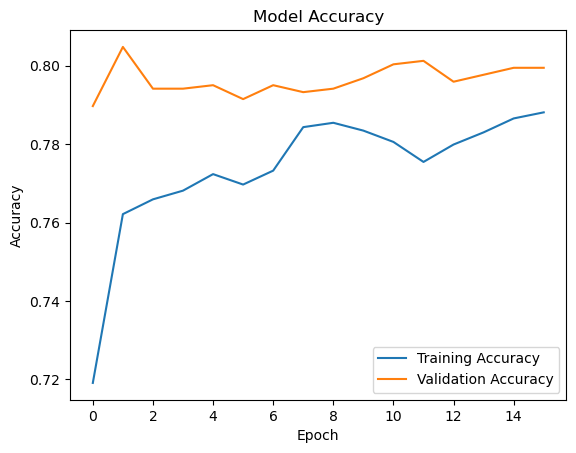

In [21]:
# Training accuray and Validation accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show() 

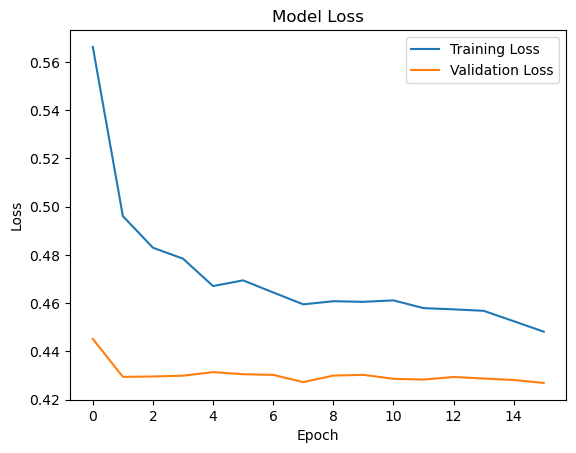

In [22]:
# Loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", cm)

Test Loss: 0.4585
Test Accuracy: 0.7871
Test AUC: 0.8049
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
 [[915 120]
 [180 194]]


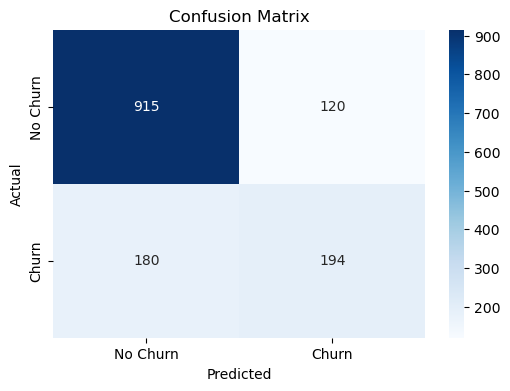

In [24]:
# Plotting Seaborn Confusion Matrix
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

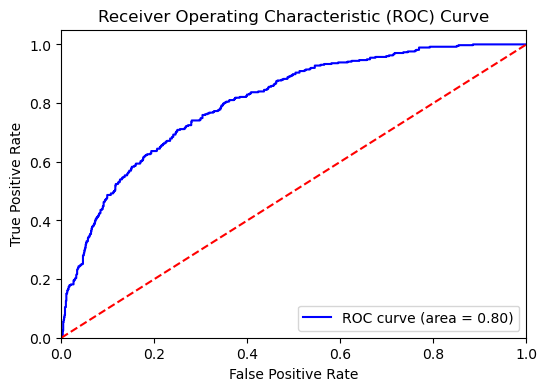

In [25]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show() 